# Calculation examples with the Oatmeal code

Here we will compute the integrals for later discussion. The fact that they are calculated with pyscf here is to exemplify that with any other integral calculator that provides the same information, the code can be used as well.

In [1]:
from pyscf import gto

mol_H2 = gto.M(atom=f"He 0 0 0")

T = mol_H2.intor("int1e_kin")
V = mol_H2.intor("int1e_nuc")
S = mol_H2.intor("int1e_ovlp")
eris = mol_H2.intor("int2e")



# Examples 
This document provides a basic description of the implementation's functionality through simple examples. For concrete results see the [Results](Results.md) section.

## Core functionality
This code is focused on complex scaled calculations. In order to describe the implementation, it is necessary to consider how it runs under the hood. 

The calculation takes place using an input struct and creates an output struct. The input struct will be from now on referred as context. The contexts currently available are: `CSRHFContext`, `CSUHFContext`, `CSRMP2Context`, and `CSUMP2Context`. These are the initial contexts for the complex scaled Restricted and Unrestricted Hartree-Fock and MP2 calculations respectively.

## RHF examples
We will start with simple RHF calculations, introducing eventually scaling and custom occupation. 

### Non-scaled RHF calculation of Helium atom


First of all, we need to define a context. Consider that this code is based (at this point) on assuming that integrals are calculated elsewhere, so we will assume that integrals `S`, `T`, `V`, and `eris` exist and are in a `ndarray`. These integrals could have been read from files, or calculated by PySCF as we will comment later. The number of electrons needs to be specified too. 

In [2]:
from py_mods.src.SCF.types import CSRHFContext

He_cxt = CSRHFContext(S, T, V, eris, 2)


Also, if we want to use directly PySCF to precompute the integrals we can use a function that interfaces with pyscf passing a dictionary, which returns a `CSRHFContext` object: 


In [3]:
from py_mods.src.SCF.external import RHF_context_from_pyscf

pyscf_args = {"atom": "He 0 0 0", "spin": 0, "charge": 0, "basis": "sto-3g"}

He_cxt = RHF_context_from_pyscf(**pyscf_args)
He_cxt.verbose = True


Now the calculation is ready to run. For this we call the `CS_RHF` function:


In [4]:
from py_mods.src.SCF.CSRHF import CS_RHF

He_results = CS_RHF(He_cxt)

--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
--------------------------------------------------------------------------------------------------------------------------------
      1     0.000000E+00+0.000000E+00j     0.000000E+00+0.000000E+00j     0.0000E+00
      2     -2.807784E+00+0.000000E+00j     -2.807784E+00+0.000000E+00j     0.0000E+00
Convergence achieved after 2 iterations.


Where all the results are stored in the `He_results` class. 

#### RHF parameters
We have introduced the basic RHF calculation. The UHF and MP2 calculations are similar in structure, just changing the context and the function called. First we will take a look at the RHF parameters that can be modified in the context, that will lead to different calculation behaviors. Currently these attrubutes are:

| Name | Optional | Type | Description |
| :--- | :--- | :--- | :--- |
| `S` | No | `NDArray[np.float64]` | Overlap matrix. |
| `T` | No | `NDArray[np.float64]` | Kinetic energy matrix. |
| `V` | No | `NDArray[np.float64]` | Nuclear attraction matrix. |
| `eri` | No | `NDArray[np.float64]` | Electron repulsion integrals. |
| `n_electrons` | No | `int` | Total electron count (must be even). |
| `theta` | Yes | `float` | Complex-scaling angle in radians (default: `0.0`). |
| `occupation` | Yes | `int`, `NDArray[np.int32]` | Occupation vector. If `None` (default), it is built automatically. |
| `max_iter` | Yes | `int` | Maximum SCF iterations (default: `100`). |
| `threshold` | Yes | `float` | Convergence threshold (default: `1e-12`). |
| `p_guess` | Yes | `{'core', 'ones', 'INPORB'}` | Initial density guess type (default: `'core'`). |
| `initial_orbitals` | Yes | `NDArray[float/complex]` | Imported orbitals. Required if `p_guess='INPORB'` (default: `None`). |
| `verbose` | Yes | `bool` | If `True`, print progress (default: `False`). |
| `conv_type` | Yes | `{'DIIS', 'CROP', None}` | Convergence algorithm (default: `'DIIS'`). |
| `acc_hist_size` | Yes | `int` | History size for convergence acceleration (default: `10`). |
| `acc_iteration_start` | Yes | `int` | Iteration to start acceleration (default: `12`). |

In these atributes we can define the complex scaling angle `theta`, the occupation, the convergence algorithm (DIIS or CROP) and parameters, the initial guess type, the maximum number of iterations, the convergence threshold, and verbose. We will briefly discuss the different options of each parameter:
- `theta`: Complex scaling angle in radians. Default is `0.0` (no scaling).
- `occupation`: Occupation vector. If `None`, it is built automatically based on the number of electrons. By passing a custom occupation vector, one can define different electronic states.
- `conv_type`: Convergence algorithm. Options are `'DIIS'` (Direct Inversion in the Iterative Subspace), `'CROP'` (Convergence acceleration by optimal parameterization), or `None` (no acceleration). Default is `'DIIS'`. The internal parameters of convergence acceleration are:
    - `acc_hist_size`: History size for convergence acceleration. This is the number of guesses stored for the extrapolation. Default is `10`.
    - `acc_iteration_start`: Iteration to start acceleration. Default is `12`.
- `p_guess`: Initial density guess type. Options are:
    - `'core'`: Core Hamiltonian guess (default).
    - `'ones'`: All ones guess.
    - `'INPORB'`: Import initial orbitals from `initial_orbitals` attribute. If selected, `initial_orbitals` must be provided.
- `max_iter`: Maximum number of SCF iterations. Default is `100`.
- `threshold`: Convergence threshold for the SCF procedure. Default is `1e-12`.
- `verbose`: If `True`, print progress during the SCF iterations. Default is `False`.

### Complex-scaled RHF calculation of Helium atom

A complex-scaled RHF calculation is as simple as defining the `theta` attribute in the context. For example, for a scaling of `0.2` radians:


In [5]:
He_cxt = RHF_context_from_pyscf(**pyscf_args)
He_cxt.verbose = True
He_cxt.theta = 0.2
He_results = CS_RHF(He_cxt)

--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
--------------------------------------------------------------------------------------------------------------------------------
      1     0.000000E+00+0.000000E+00j     0.000000E+00+0.000000E+00j     0.0000E+00
      2     -2.807784E+00+0.000000E+00j     -2.807784E+00+0.000000E+00j     0.0000E+00
Convergence achieved after 2 iterations.
Converging unscaled case:
--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
----------------------------------------------------------------------------------------------------------------



Here the final energy has a small imaginary part, corresponding to the resonance width.

### Custom occupation RHF calculation of He atom
In order to define a custom occupation, we can pass an occupation vector to the context. For example, to define an excited singled state in Helium ($2s2$), we can do:


In [6]:
import numpy as np

He_cxt = RHF_context_from_pyscf(**pyscf_args)
He_cxt.verbose = True
He_cxt.occupation = np.array([0, 2, 0, 0])

He_results = CS_RHF(He_cxt)

--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
--------------------------------------------------------------------------------------------------------------------------------
      1     0.000000E+00+0.000000E+00j     0.000000E+00+0.000000E+00j     0.0000E+00
      2     0.000000E+00+0.000000E+00j     0.000000E+00+0.000000E+00j     0.0000E+00
Convergence achieved after 2 iterations.


With a higher energy than the one of the ground state ($-2.8615$).

### CS calculation of an excited state
Now, combining both previous examples, we can compute a complex-scaled RHF calculation of the excited $2s2$ state of Helium:


In [7]:
He_cxt = RHF_context_from_pyscf(**pyscf_args)
He_cxt.verbose = True
He_cxt.theta = 0.01
He_cxt.occupation = np.array([0, 2, 0, 0])

He_results = CS_RHF(He_cxt)

--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
--------------------------------------------------------------------------------------------------------------------------------
      1     0.000000E+00+0.000000E+00j     0.000000E+00+0.000000E+00j     0.0000E+00
      2     0.000000E+00+0.000000E+00j     0.000000E+00+0.000000E+00j     0.0000E+00
Convergence achieved after 2 iterations.
Converging unscaled case:
--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
------------------------------------------------------------------------------------------------------------------



Where the scaled energy possesses now a small imaginary part, corresponding to the resonance width of the excited state.

### CSRHF theta trajectories
The complex scaling angle `theta` can be varied to create theta trajectories. This is done by running several calculations with different `theta` values. For example, to create a theta trajectory for Helium from `0.0` to `0.8` radians in $9$ steps we can use:


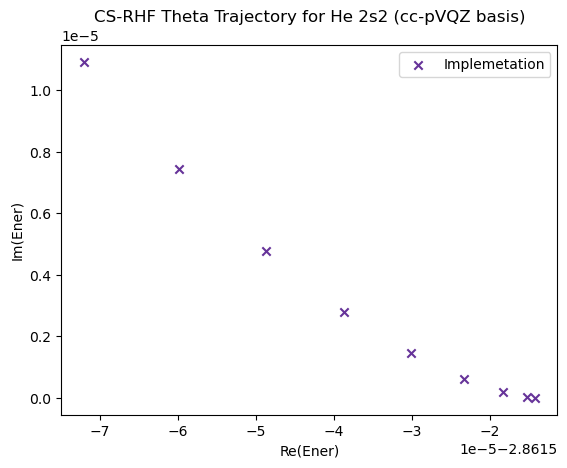

In [8]:
from py_mods.src.SCF.CSRHF import rhf_theta_traj
import matplotlib.pyplot as plt

pyscf_args = {"atom": "He 0 0 0", "spin": 0, "charge": 0, "basis": "cc-pvqz"}
He_cxt = RHF_context_from_pyscf(**pyscf_args)
traj_ener_2 = rhf_theta_traj(0.08, 9, He_cxt)

He_2s2_qz_gs = np.array(traj_ener_2[1])

plt.scatter(
    He_2s2_qz_gs.real,
    He_2s2_qz_gs.imag,
    label="Implemetation",
    c="RebeccaPurple",
    marker="x",
)
plt.title("CS-RHF Theta Trajectory for He 2s2 (cc-pVQZ basis)")
plt.legend()
plt.xlabel("Re(Ener)")
plt.ylabel("Im(Ener)")
plt.show()

Where each point (from right to left) corresponds to an increase of $0.01$ in $\theta$. 

## MP2 examples 
The MP2 calculations are very similar to the RHF ones, just changing the context and the function called. The context for a MP2 calculation is the results of a previous SCF calculation. In particular, the context can be a `CSRHFResults` or a `CSUHFResults` object.

In [9]:
from py_mods.src.MP2.CSMP2 import CS_MP2
pyscf_args = {"atom": "He 0 0 0", "spin": 0, "charge": 0, "basis": "cc-pvqz"}
He_cxt = RHF_context_from_pyscf(**pyscf_args)

He_results = CS_RHF(He_cxt)
He_MP2_results = CS_MP2(He_results)


Where we can extract the values from this object:


In [10]:
print(f"Correlation energy (MP2): {He_MP2_results.E_corr.real:4e}")
print(f"Total energy (RHF + MP2): {He_MP2_results.E_MP2.real:4e}")

Correlation energy (MP2): -3.547800e-02
Total energy (RHF + MP2): -2.896992e+00



### Complex-scaled MP2 calculation
Similarly to the RHF case, we can perform a complex-scaled MP2 calculation by providing a complex-scaled SCF results object as context. For example, using the previously calculated complex-scaled RHF results:


In [11]:
He_cxt = RHF_context_from_pyscf(**pyscf_args)
He_cxt.theta = 0.2
He_results_cs = CS_RHF(He_cxt)
He_MP2_results_cs = CS_MP2(He_results_cs)

Unpacking:

In [12]:
print(f"Correlation energy (MP2): {He_MP2_results_cs.E_corr:4e}")
print(f"Total energy (RHF + MP2): {He_MP2_results_cs.E_MP2:4e}")

Correlation energy (MP2): -3.579815e-02+1.005355e-04j
Total energy (RHF + MP2): -2.897422e+00+2.019413e-04j



### MP2 calculation with excited states 
Similarly to the RHF case, we can define custom occupations in the SCF calculation before performing the MP2 calculation. For example, defining the $2s2$ excited state in Helium:


In [13]:
pyscf_args = {"atom": "He 0 0 0", "spin": 0, "charge": 0, "basis": "cc-pvqz"}
He_cxt = RHF_context_from_pyscf(**pyscf_args)
He_cxt.occupation = np.array([0, 2, 0, 0])

He_results = CS_RHF(He_cxt)
He_MP2_results = CS_MP2(He_results)


We can get the results as previously:


In [14]:
print(f"Correlation energy (MP2): {He_MP2_results.E_corr.real:4e}")
print(f"Total energy (RHF + MP2): {He_MP2_results.E_MP2.real:4e}")

Correlation energy (MP2): -8.418459e-03
Total energy (RHF + MP2): -4.937544e-01




And both can be combined as in the SCF case to perform a complex-scaled MP2 calculation of an excited state:


In [15]:
pyscf_args = {"atom": "He 0 0 0", "spin": 0, "charge": 0, "basis": "cc-pvqz"}
He_cxt = RHF_context_from_pyscf(**pyscf_args)

He_cxt.theta = 0.01
He_cxt.occupation = np.array([0, 2, 0, 0])
He_results_cs = CS_RHF(He_cxt)

He_MP2_results_cs = CS_MP2(He_results_cs)

In [16]:
print(f"Correlation energy (MP2): {He_MP2_results_cs.E_corr:4e}")
print(f"Total energy (RHF + MP2): {He_MP2_results_cs.E_MP2:4e}")

Correlation energy (MP2): -8.415778e-03-1.970474e-04j
Total energy (RHF + MP2): -4.940176e-01-1.249925e-02j
